In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib

In [2]:
df = pd.read_csv("../dataset/dataset.csv")

In [3]:
df.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,75,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
4,118,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False


In [4]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [5]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
print("Numerical Features:", numerical_features)

categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()
print("Categorical Features:", categorical_features)

Numerical Features: ['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']
Categorical Features: ['International plan', 'Voice mail plan']


In [6]:
# Split 80% train, 20% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Split 20% tadi jadi 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 2237 | Val: 280 | Test: 280


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

In [9]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_processed,   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_processed,  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).reshape(-1, 1)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32).reshape(-1, 1)

In [10]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = torch.utils.data.TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = torch.utils.data.TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

input_dim = X_train_processed.shape[1]
print('Input dim:', input_dim)

Input dim: 19


MLP Model

In [11]:
input_dim = X_train_processed.shape[1] # cek berapa fitur

In [12]:
from mlp import MLP

model = MLP(input_dim=input_dim) # MLP == ANN

In [13]:
criterion = nn.BCEWithLogitsLoss() # untuk loss nya

In [14]:
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001
) # untuk optimisasi

In [15]:
num_epochs = 50
train_losses = []
val_losses   = []

In [16]:
for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}")

Epoch [1/50] Train Loss: 0.4487 | Val Loss: 0.3093
Epoch [2/50] Train Loss: 0.2655 | Val Loss: 0.2150
Epoch [3/50] Train Loss: 0.2429 | Val Loss: 0.1937
Epoch [4/50] Train Loss: 0.2282 | Val Loss: 0.1706
Epoch [5/50] Train Loss: 0.2178 | Val Loss: 0.1816
Epoch [6/50] Train Loss: 0.2069 | Val Loss: 0.1602
Epoch [7/50] Train Loss: 0.2168 | Val Loss: 0.1697
Epoch [8/50] Train Loss: 0.1971 | Val Loss: 0.1670
Epoch [9/50] Train Loss: 0.2029 | Val Loss: 0.1582
Epoch [10/50] Train Loss: 0.1958 | Val Loss: 0.1497
Epoch [11/50] Train Loss: 0.1797 | Val Loss: 0.1499
Epoch [12/50] Train Loss: 0.1792 | Val Loss: 0.1473
Epoch [13/50] Train Loss: 0.1863 | Val Loss: 0.1457
Epoch [14/50] Train Loss: 0.1860 | Val Loss: 0.1417
Epoch [15/50] Train Loss: 0.1778 | Val Loss: 0.1459
Epoch [16/50] Train Loss: 0.1762 | Val Loss: 0.1481
Epoch [17/50] Train Loss: 0.1740 | Val Loss: 0.1464
Epoch [18/50] Train Loss: 0.1701 | Val Loss: 0.1457
Epoch [19/50] Train Loss: 0.1748 | Val Loss: 0.1346
Epoch [20/50] Train L

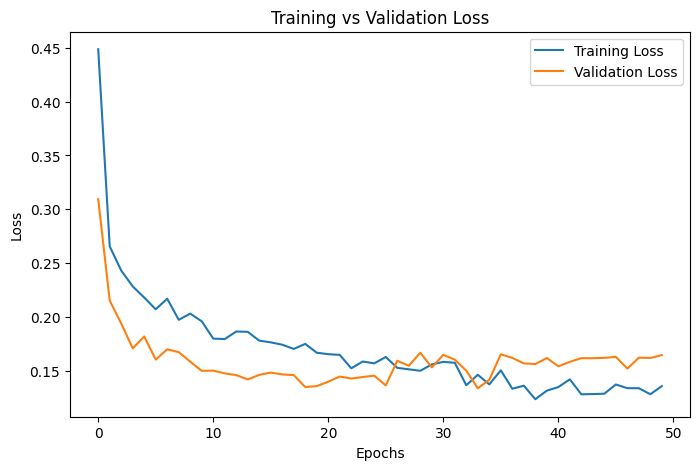

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [18]:
model.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [19]:
with torch.no_grad():

    logits = model(
        X_test_tensor
    )

    probs = torch.sigmoid(
        logits
    )

    y_prob = probs.numpy()

    y_pred = (
        y_prob > 0.5
    ).astype(int)

In [20]:
acc = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_pred
)

In [21]:
print(f"Accuracy : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC : {auc:.4f}")


Accuracy : 0.9607
Precision : 0.9167
Recall : 0.7097
F1 Score : 0.8000
ROC AUC : 0.8508


In [25]:
torch.save(model.state_dict(), "churn_model.pth")

In [26]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [27]:
print(X_train_processed.shape)

(2237, 19)
